In [1]:
# Import standard data science libraries for analysis, visualization, and array handling
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the Telco customer churn dataset from the CSV file
# Adjust the path if the notebook is moved to a different location
df=pd.read_csv(r'C:\Users\yusuf\Desktop\DataScience Journey\Orange\Tasks\Final Project\Dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
# Preview the first rows of the dataset to verify the content and columns
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [5]:
# Inspect the data types and check for missing values in each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Get descriptive statistics for numerical features
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.describe(include='O').T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [8]:
# Check how many missing values exist in each column before imputation
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# Identify rows where TotalCharges contains an empty string instead of a numeric value
df[df['TotalCharges']==' '].transpose()

,488,753,936,1082,1340,3331,3826,4380,5218,6670,6754
customerID,4472-LVYGI,3115-CZMZD,5709-LVOEQ,4367-NUYAO,1371-DWPAZ,7644-OMVMY,3213-VVOLG,2520-SGTTA,2923-ARZLG,4075-WKNIU,2775-SEFEE
gender,Female,Male,Female,Male,Female,Male,Male,Female,Male,Female,Male
SeniorCitizen,0,0,0,0,0,0,0,0,0,0,0
Partner,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No
Dependents,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
tenure,0,0,0,0,0,0,0,0,0,0,0
PhoneService,No,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes
MultipleLines,No phone service,No,No,Yes,No phone service,No,Yes,No,No,Yes,Yes
InternetService,DSL,No,DSL,No,DSL,No,No,No,No,DSL,DSL
OnlineSecurity,Yes,No internet service,Yes,No internet service,Yes,No internet service,No internet service,No internet service,No internet service,No,Yes


In [11]:
df[df['TotalCharges']==' '].count()

customerID          11
gender              11
SeniorCitizen       11
Partner             11
Dependents          11
tenure              11
PhoneService        11
MultipleLines       11
InternetService     11
OnlineSecurity      11
OnlineBackup        11
DeviceProtection    11
TechSupport         11
StreamingTV         11
StreamingMovies     11
Contract            11
PaperlessBilling    11
PaymentMethod       11
MonthlyCharges      11
TotalCharges        11
Churn               11
dtype: int64

In [12]:
# Convert TotalCharges to numeric, coercing invalid strings to NaN so they can be handled consistently
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [14]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [15]:
df.TotalCharges.describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

In [16]:
# Replace missing TotalCharges values with the median to avoid dropping potentially useful rows
df['TotalCharges']=df.TotalCharges.fillna(df.TotalCharges.median())

In [17]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
# Normalize column names to lowercase to make later references consistent
df.columns=df.columns.str.lower()

In [19]:
df.isna().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [20]:
df.churn.value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [21]:
df.head().transpose()

,0,1,2,3,4
customerid,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
seniorcitizen,0,0,0,0,0
partner,Yes,No,No,No,No
dependents,No,No,No,No,No
tenure,1,34,2,45,2
phoneservice,No,Yes,Yes,No,Yes
multiplelines,No phone service,No,No,No phone service,No
internetservice,DSL,DSL,DSL,DSL,Fiber optic
onlinesecurity,No,Yes,Yes,Yes,No


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


In [23]:
# Treat seniorcitizen as a categorical feature rather than a numeric one
df["seniorcitizen"]=df.seniorcitizen.astype('object')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   object 
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


In [25]:
df.to_csv(r'C:\Users\yusuf\Desktop\DataScience Journey\Orange\Tasks\Final Project\Dataset\cleaned_telco_churn.csv',index=False)

In [26]:
# Drop the customerID column because it is a unique identifier without predictive value
df.drop('customerid',axis=1,inplace=True)
# Convert churn from Yes/No to binary labels that can be used by classifiers
df.churn=df.churn.map({'Yes':1,'No':0})
df.head().transpose()

,0,1,2,3,4
gender,Female,Male,Male,Male,Female
seniorcitizen,0,0,0,0,0
partner,Yes,No,No,No,No
dependents,No,No,No,No,No
tenure,1,34,2,45,2
phoneservice,No,Yes,Yes,No,Yes
multiplelines,No phone service,No,No,No phone service,No
internetservice,DSL,DSL,DSL,DSL,Fiber optic
onlinesecurity,No,Yes,Yes,Yes,No
onlinebackup,Yes,No,Yes,No,No


In [27]:
# Data splitting: create training, validation, and test sets for model development
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_valid = train_test_split(df_full_train, test_size=0.2, random_state=1)
print("Training Data Size: ", df_train.shape)
print("Validation Data Size: ", df_valid.shape)
print("Testing Data Size: ", df_test.shape)

Training Data Size:  (4507, 20)
Validation Data Size:  (1127, 20)
Testing Data Size:  (1409, 20)


In [28]:
# Identify categorical and numerical feature columns in the training set
categorical=list(df_train.select_dtypes(include=['object']).columns)
numerical=list(df_train.select_dtypes(include=['int64','float64']).columns)

In [29]:
categorical

['gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod']

In [30]:
numerical

['tenure', 'monthlycharges', 'totalcharges', 'churn']

In [31]:
numerical.remove('churn')

In [32]:
numerical

['tenure', 'monthlycharges', 'totalcharges']

In [33]:
# Check the number of unique categories in each categorical feature
df_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

In [34]:
# Calculate the global churn rate so we can compare each category against it
global_risk=df_train.churn.mean()
round(global_risk,2)

np.float64(0.27)

In [35]:
churn_gender=df_train.groupby('gender').churn.mean()
churn_gender

gender
Female    0.274258
Male      0.261778
Name: churn, dtype: float64

In [36]:
#the difference between male and female customers is not significant in terms of churn rate. Both are around the global risk of 0.27, so we can exclude this feature from our model.


In [37]:
churn_partner=df_train.groupby('partner').churn.mean()
churn_partner

partner
No     0.325838
Yes    0.204651
Name: churn, dtype: float64

In [38]:
gender_risk=churn_gender/global_risk
gender_risk

gender
Female    1.023245
Male      0.976682
Name: churn, dtype: float64

In [39]:
partner_risk=churn_partner/global_risk
partner_risk

partner
No     1.215688
Yes    0.763545
Name: churn, dtype: float64

In [40]:
# Display churn mean, difference, and risk ratio for each category of every categorical feature
from IPython.display import display
for feature in categorical:
    df_grouped=df_train.groupby(by=feature).churn.agg(['mean'])
    df_grouped['difference']=df_grouped['mean']-global_risk
    df_grouped['risk_ratio']=df_grouped['mean']/global_risk
    display(df_grouped)
    

,mean,difference,risk_ratio
gender,,,
Female,0.274258,0.00623,1.023245
Male,0.261778,-0.00625,0.976682


,mean,difference,risk_ratio
seniorcitizen,,,
0,0.241700,-0.026328,0.901773
1,0.401617,0.133590,1.498418


,mean,difference,risk_ratio
partner,,,
No,0.325838,0.057810,1.215688
Yes,0.204651,-0.063376,0.763545


,mean,difference,risk_ratio
dependents,,,
No,0.312599,0.044572,1.166295
Yes,0.164454,-0.103573,0.613572


,mean,difference,risk_ratio
phoneservice,,,
No,0.249438,-0.018589,0.930644
Yes,0.270064,0.002036,1.007598


...

,mean,difference,risk_ratio
streamingtv,,,
No,0.344674,0.076646,1.285964
No internet service,0.080080,-0.187947,0.298776
Yes,0.297376,0.029349,1.109498


,mean,difference,risk_ratio
streamingmovies,,,
No,0.338609,0.070582,1.263338
No internet service,0.080080,-0.187947,0.298776
Yes,0.304198,0.036170,1.134950


,mean,difference,risk_ratio
contract,,,
Month-to-month,0.432509,0.164482,1.613674
One year,0.115822,-0.152205,0.432128
Two year,0.027027,-0.241000,0.100837


,mean,difference,risk_ratio
paperlessbilling,,,
No,0.171566,-0.096462,0.640106
Yes,0.336495,0.068467,1.255448


,mean,difference,risk_ratio
paymentmethod,,,
Bank transfer (automatic),0.164622,-0.103406,0.614197
Credit card (automatic),0.175620,-0.092408,0.655231
Electronic check,0.441215,0.173188,1.646157
Mailed check,0.199618,-0.068410,0.744767


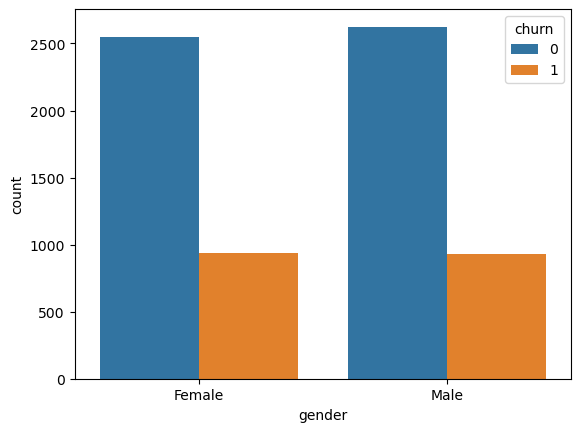

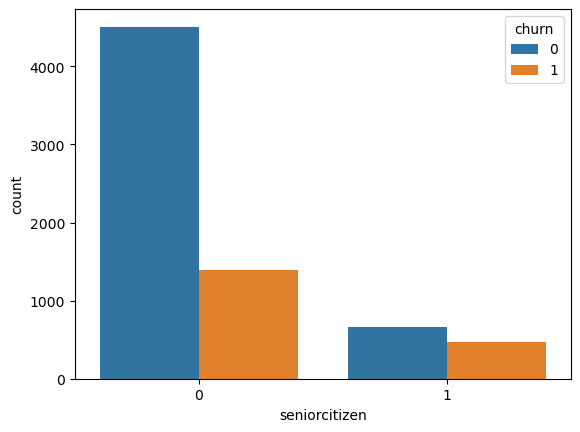

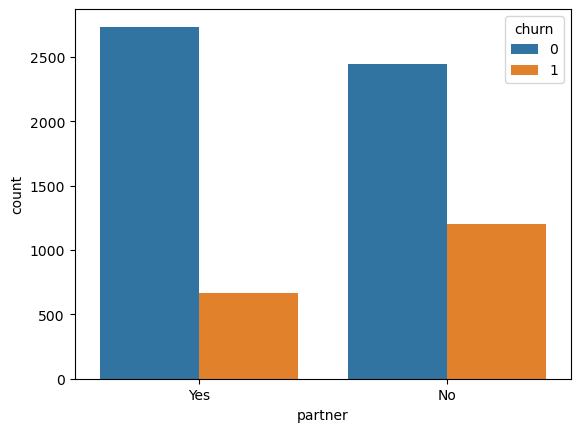

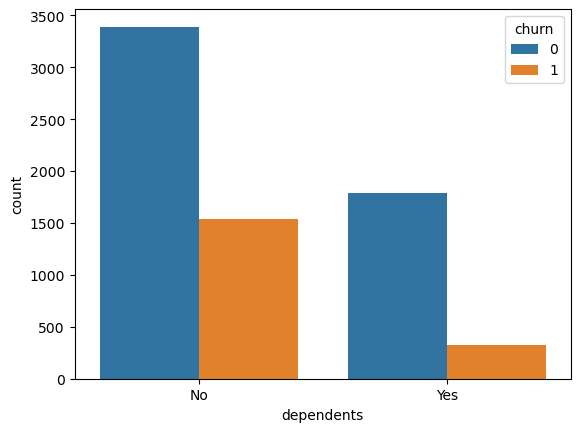

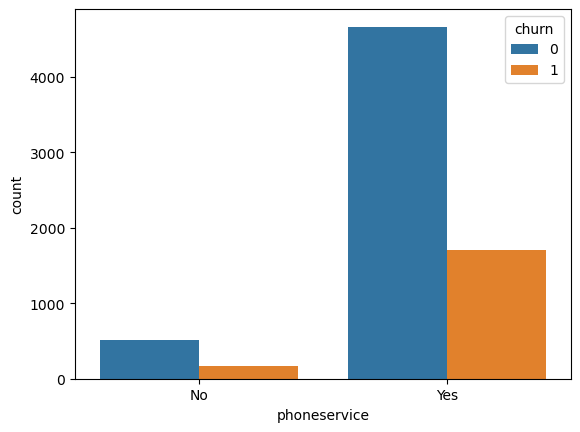

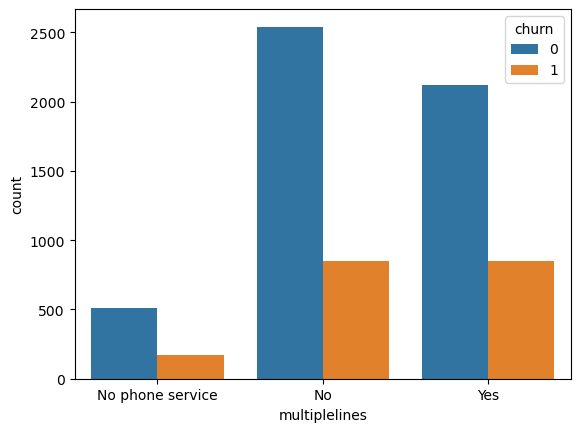

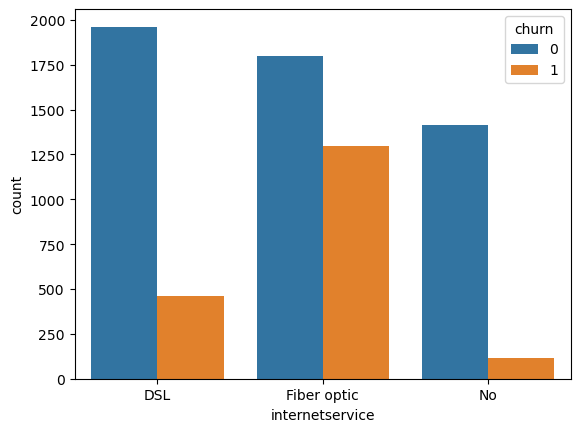

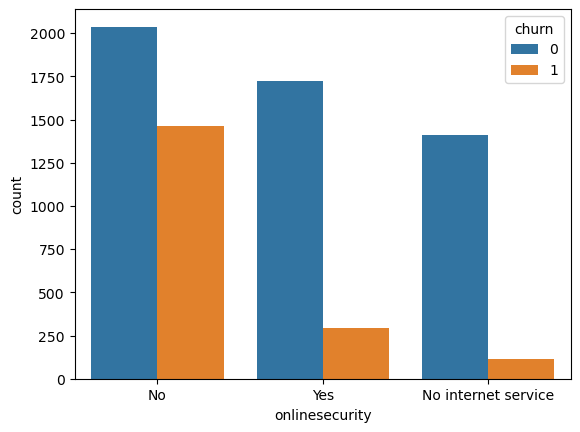

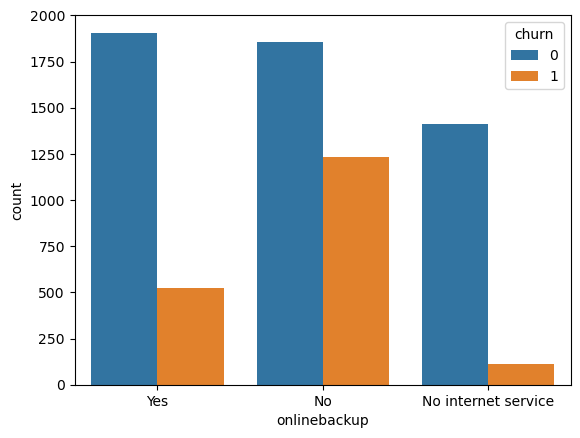

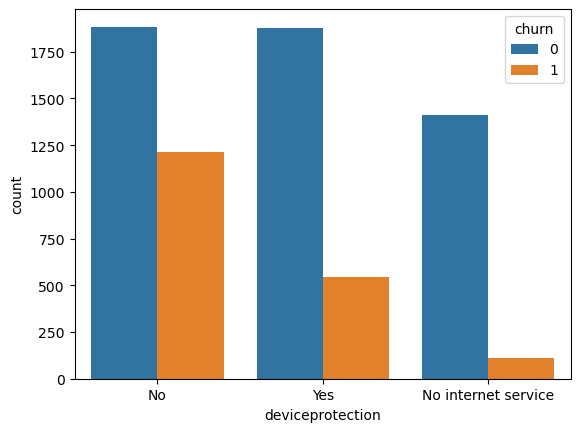

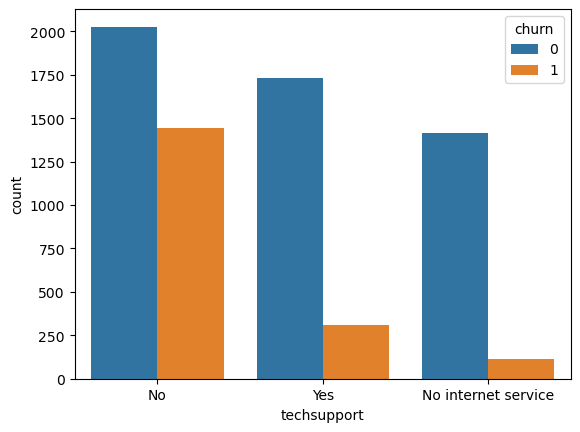

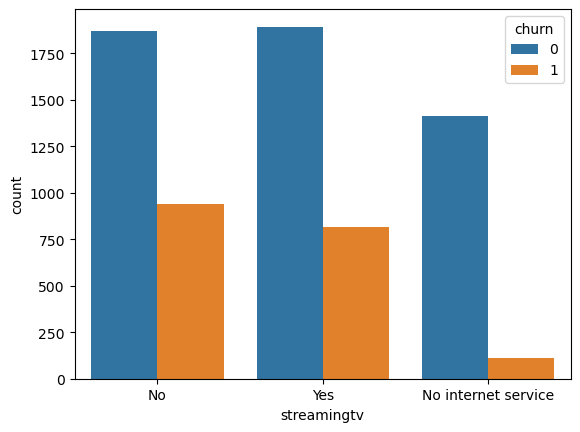

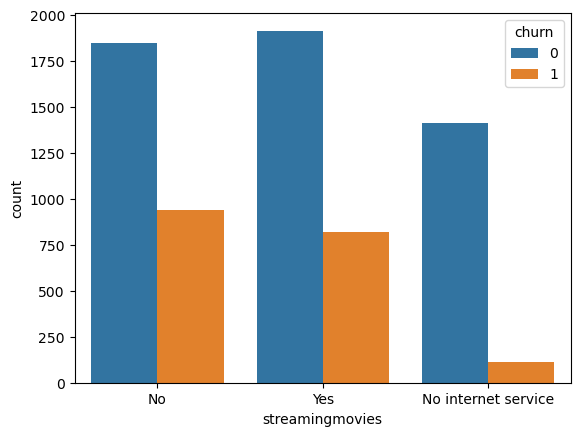

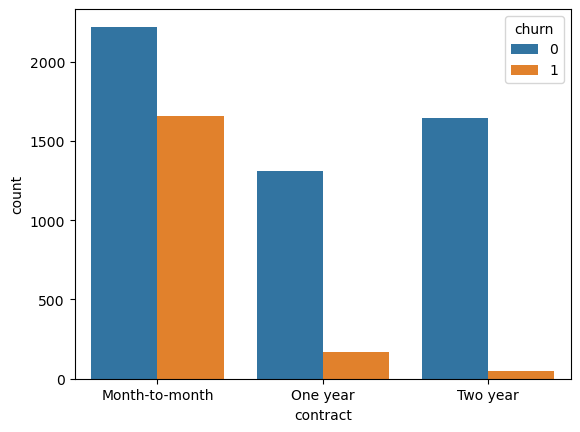

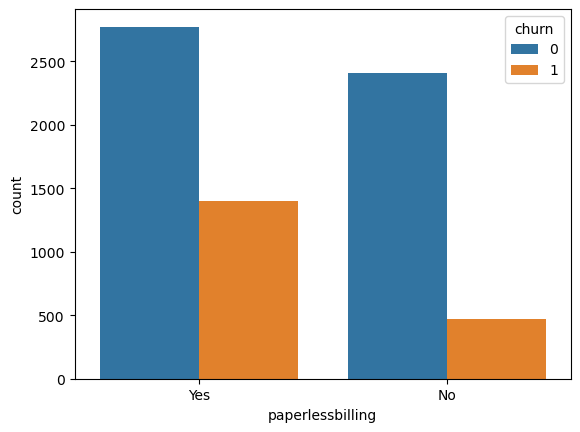

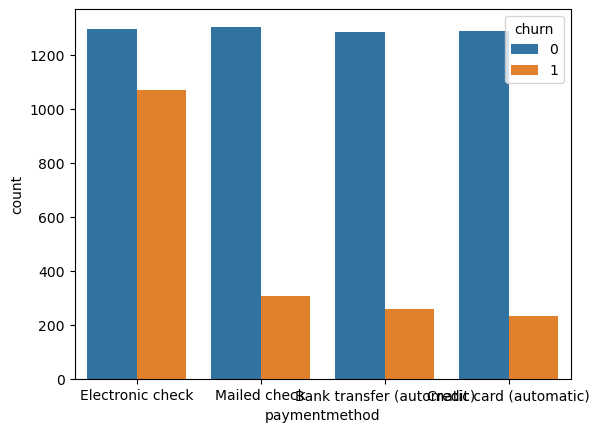

In [41]:
# Visualize category counts by churn status for each categorical variable
for feature in categorical:
   sns.countplot(x=feature,data=df,hue='churn')
   plt.show()

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1111399775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')


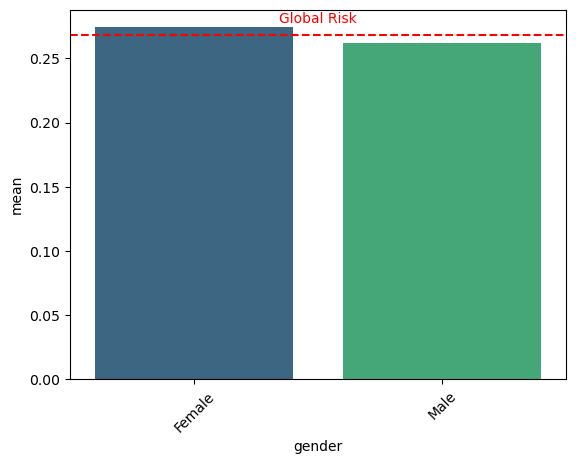

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1111399775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')


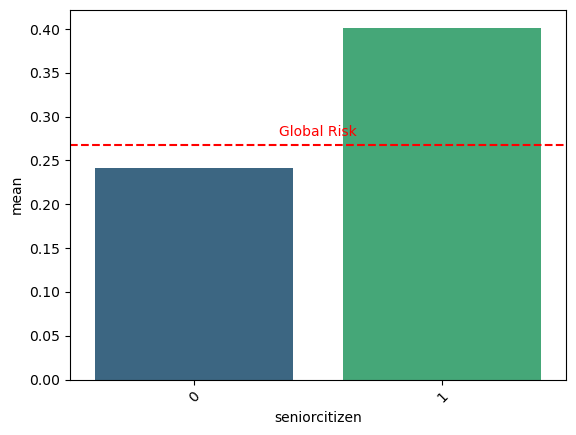

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1111399775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')


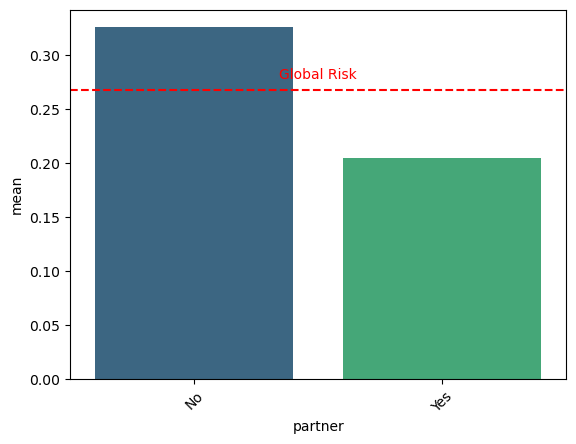

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1111399775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')


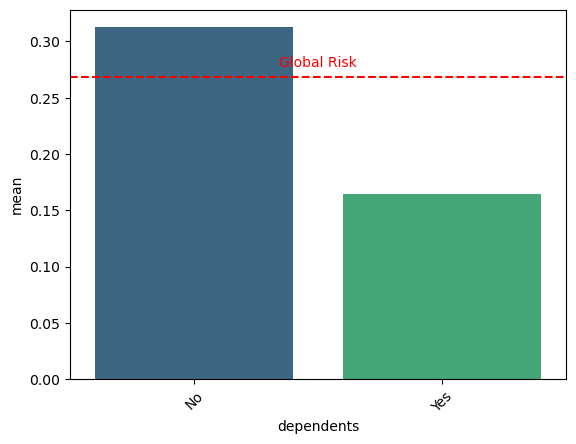

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1111399775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')


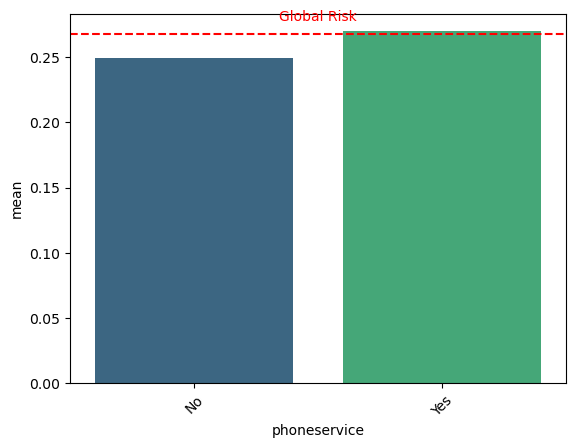

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1111399775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')


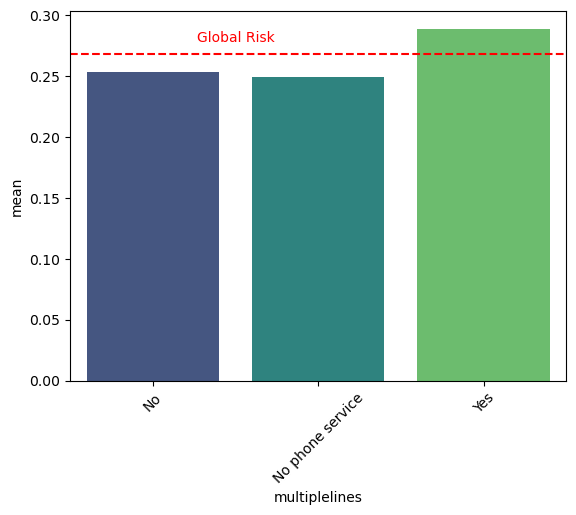

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1111399775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')


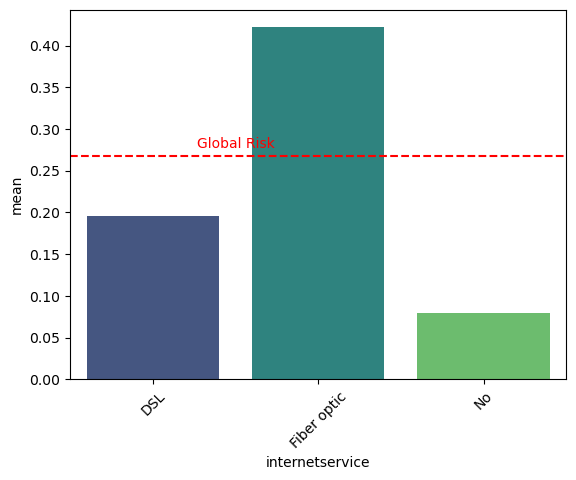

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1111399775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')


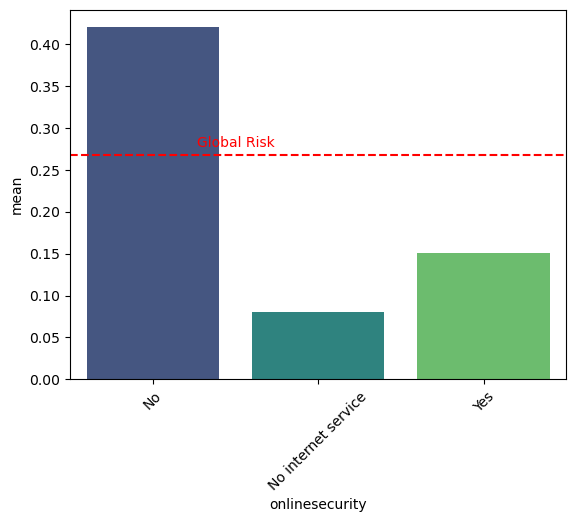

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1111399775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')


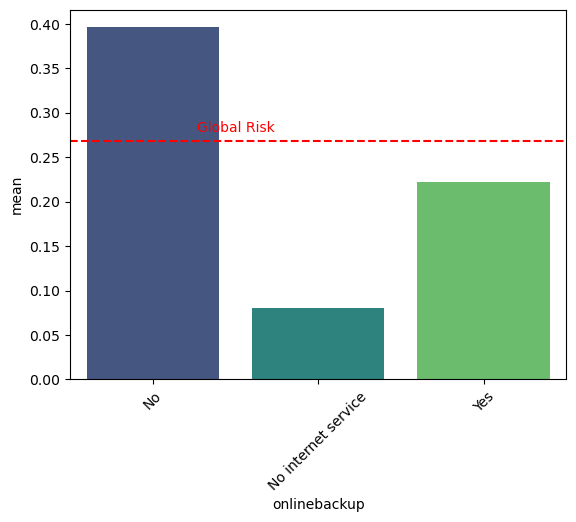

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1111399775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')


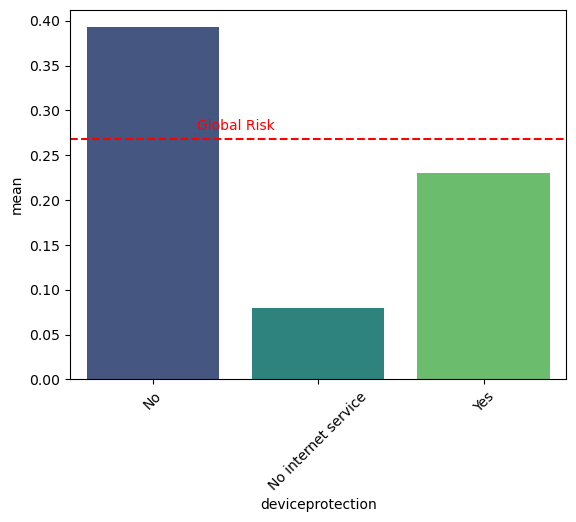

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1111399775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')


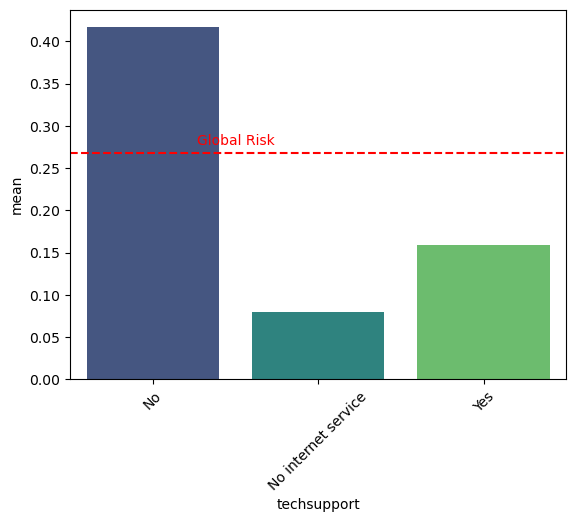

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1111399775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')


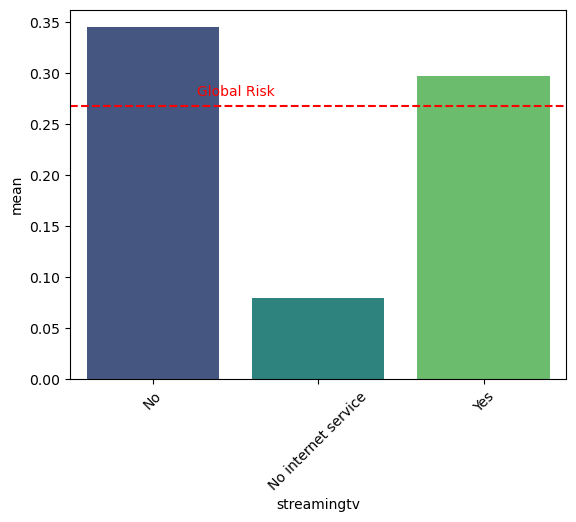

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1111399775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')


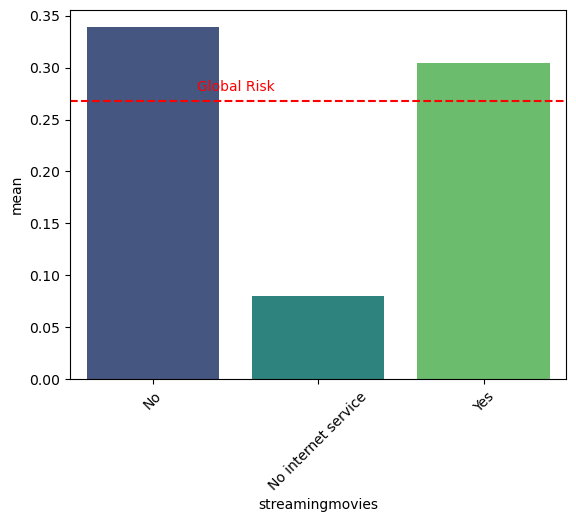

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1111399775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')


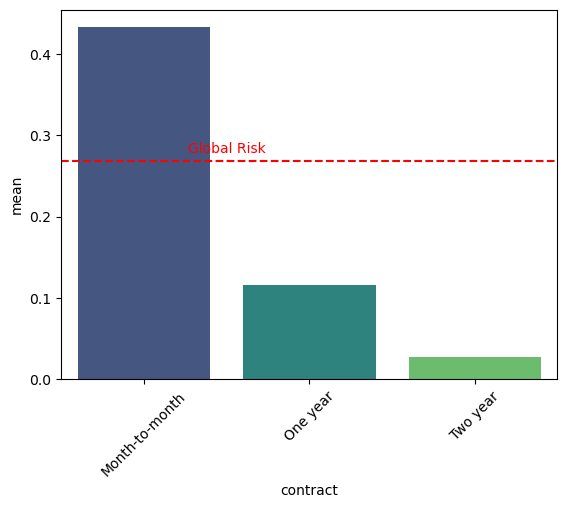

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1111399775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')


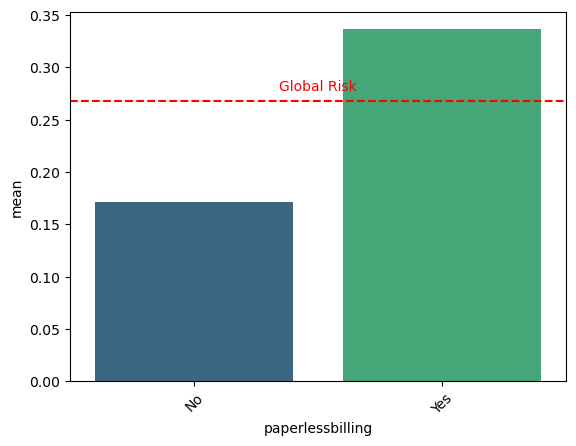

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1111399775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')


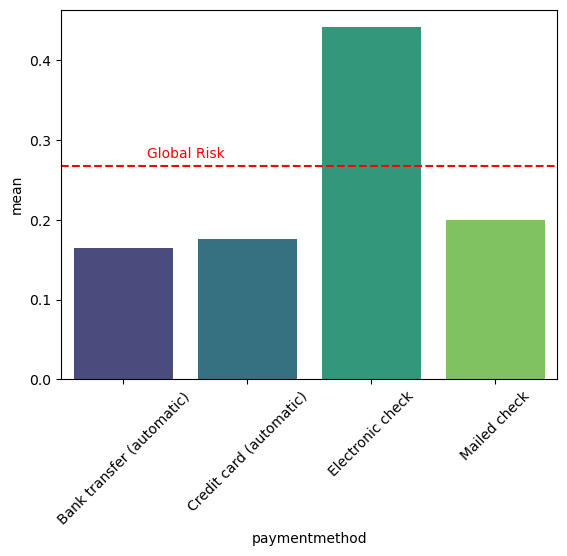

In [42]:
# Plot churn rate for each category and compare it against the global churn rate
for feature in categorical:
    df_grouped=df_train.groupby(by=feature).churn.agg(['mean']).reset_index()
    graph=sns.barplot(x=feature,y='mean',data=df_grouped, palette='viridis')
    graph.axhline(global_risk, color='red', linestyle='--')
    plt.text(0.5, global_risk+0.01, 'Global Risk', color='red', ha='center')
    plt.xticks(rotation=45)
    plt.show()

In [43]:
# Compute mutual information between each categorical feature and churn to estimate feature importance
from sklearn.metrics import mutual_info_score
def calculate_mutual_info(series):
    return mutual_info_score(series, df_train.churn)

df_mi=df_train[categorical].apply(calculate_mutual_info)
df_mi=df_mi.sort_values(ascending=False).to_frame(name='mutual_info')
display(df_mi.head(10))
display(df_mi.tail(10))

,mutual_info
contract,0.100378
onlinesecurity,0.062802
techsupport,0.059945
internetservice,0.053951
onlinebackup,0.044230
deviceprotection,0.042465
paymentmethod,0.037791
streamingtv,0.031625
streamingmovies,0.031155
paperlessbilling,0.017462


,mutual_info
paymentmethod,0.037791
streamingtv,0.031625
streamingmovies,0.031155
paperlessbilling,0.017462
dependents,0.012528
partner,0.009443
seniorcitizen,0.008396
multiplelines,0.000821
gender,0.000099
phoneservice,0.000098


In [44]:
# Check correlation between numerical features and churn to identify the strongest numeric predictors
df[numerical].corrwith(df.churn).sort_values(ascending=False)

monthlycharges    0.193356
totalcharges     -0.199037
tenure           -0.352229
dtype: float64

In [45]:
t1=df[df["tenure"]<2].churn.mean()
t1

np.float64(0.6089743589743589)

In [46]:
t2=df[(df["tenure"]>3) & (df["tenure"]<12)].churn.mean()
t2

np.float64(0.39920556107249255)

In [47]:
t3=df[df["tenure"]>12].churn.mean()
t3

np.float64(0.17129915585752523)

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\2496280964.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['-2','3-12 ','12+'],y=[t1,t2,t3], palette='viridis')


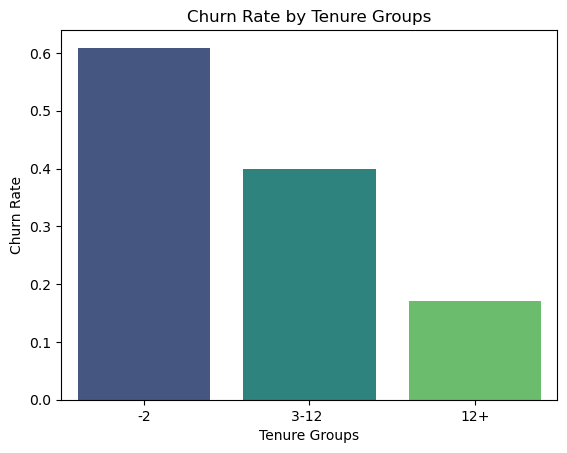

In [48]:
sns.barplot(x=['-2','3-12 ','12+'],y=[t1,t2,t3], palette='viridis')
plt.title('Churn Rate by Tenure Groups')
plt.xlabel('Tenure Groups')
plt.ylabel('Churn Rate')
plt.show()


In [49]:
mc1=df[df['monthlycharges']<=20].churn.mean()
mc1

np.float64(0.08841463414634146)

In [50]:
mc2=df[(df['monthlycharges']>=21) & (df['monthlycharges']<=50)].churn.mean()
mc2

np.float64(0.22807017543859648)

In [51]:
mc3=df[df['monthlycharges']>50].churn.mean()
mc3

np.float64(0.3178752107925801)

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1142909160.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[ '0-20', '21-50', '50+' ],y=[mc1,mc2,mc3], palette='viridis')


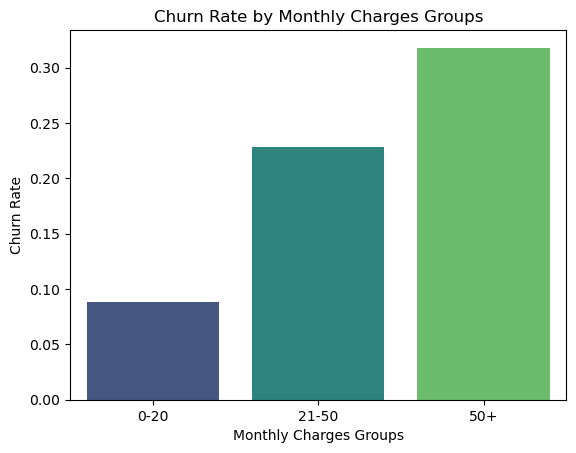

In [52]:
sns.barplot(x=[ '0-20', '21-50', '50+' ],y=[mc1,mc2,mc3], palette='viridis')
plt.title('Churn Rate by Monthly Charges Groups')
plt.xlabel('Monthly Charges Groups')
plt.ylabel('Churn Rate')
plt.show()

In [53]:
tc1=df[df['totalcharges']<=1000].churn.mean()
tc1

np.float64(0.36985827860352577)

In [54]:
tc2=df[(df['totalcharges']>1000) & (df['totalcharges']<=5000)].churn.mean()
tc2

np.float64(0.21293532338308457)

In [55]:
tc3=df[df['totalcharges']>5000].churn.mean()
tc3

np.float64(0.13832599118942732)

C:\Users\yusuf\AppData\Local\Temp\ipykernel_1328\1956953077.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["0-1000","1000-5000","5000+"],y=[tc1,tc2,tc3], palette='viridis')


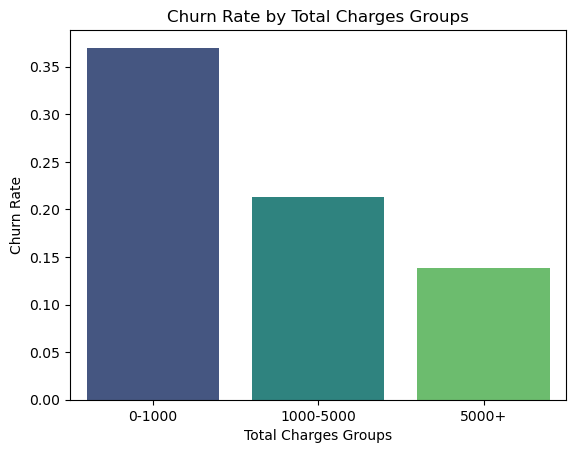

In [56]:
sns.barplot(x=["0-1000","1000-5000","5000+"],y=[tc1,tc2,tc3], palette='viridis')
plt.title('Churn Rate by Total Charges Groups')
plt.xlabel('Total Charges Groups')
plt.ylabel('Churn Rate')
plt.show()

In [57]:
# Encode categorical variables using one-hot encoding and leave numeric features unchanged
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer

ohe = OneHotEncoder(drop='first')

transformer = make_column_transformer((ohe, categorical), remainder='passthrough',
                                      verbose_feature_names_out=False)

train_enc = transformer.fit_transform(df_train)
df_train_enc = pd.DataFrame(train_enc, columns=transformer.get_feature_names_out())
df_train_enc

,gender_Male,seniorcitizen_1,partner_Yes,dependents_Yes,phoneservice_Yes,multiplelines_No phone service,multiplelines_Yes,internetservice_Fiber optic,internetservice_No,onlinesecurity_No internet service,...,contract_One year,contract_Two year,paperlessbilling_Yes,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check,tenure,monthlycharges,totalcharges,churn
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,30.0,19.70,625.05,0.0
1,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,23.0,83.75,1849.95,0.0
2,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,14.0,95.80,1346.30,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,56.0,19.70,1051.90,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,63.0,98.00,6218.45,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4502,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,52.0,80.85,4079.55,0.0
4503,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,18.0,25.15,476.80,0.0
4504,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,90.00,190.05,1.0
4505,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,27.0,24.50,761.95,0.0


In [58]:
X_train = df_train_enc.drop('churn', axis=1)
y_train = df_train_enc['churn']

In [59]:
valid_enc = transformer.transform(df_valid)
df_valid_enc = pd.DataFrame(valid_enc, columns=transformer.get_feature_names_out())
X_valid = df_valid_enc.drop('churn', axis=1)
y_valid = df_valid_enc['churn']

test_enc = transformer.transform(df_test)
df_test_enc = pd.DataFrame(test_enc, columns=transformer.get_feature_names_out())
X_test = df_test_enc.drop('churn', axis=1)
y_test = df_test_enc['churn']

In [60]:
# Inspect numeric feature distributions before scaling
df_train[numerical].describe()

,tenure,monthlycharges,totalcharges
count,4507.000000,4507.000000,4507.000000
mean,32.001553,64.312536,2239.464489
std,24.558539,30.089423,2247.288739
min,0.000000,18.250000,18.800000
25%,8.000000,34.700000,386.850000
50%,28.000000,70.150000,1363.450000
75%,55.000000,89.575000,3708.000000
max,72.000000,118.350000,8684.800000


In [61]:
# Scale numeric features so that they have zero mean and unit variance for model training
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit_transform(df_train[numerical])

array([[-0.08151035, -1.48282956, -0.71846292],
       [-0.36657522,  0.64606159, -0.17334564],
       [-0.7330872 ,  1.04657898, -0.39748501],
       ...,
       [-1.22176983,  0.85379883, -0.91205098],
       [-0.20368101, -1.32328737, -0.65753831],
       [-0.93670496,  0.54967152, -0.66212211]])

In [62]:
# Define a reusable preprocessing pipeline for numeric and categorical data
def preprocess(df_train, df_valid, df_test, num, cat):
    # Define transformers
    ohe = OneHotEncoder(drop='first')
    scaler = StandardScaler()

    transformer = make_column_transformer((scaler, num),
                                           (ohe, cat),
                                          remainder='passthrough',verbose_feature_names_out=False)
    # Fitting & transformation
    X_train = transformer.fit_transform(df_train[cat+num])
    X_valid = transformer.transform(df_valid[cat+num])
    X_test = transformer.transform(df_test[cat+num])
    columns=transformer.get_feature_names_out()
   
    return X_train , X_valid, X_test, columns

In [63]:
X_train , X_valid, X_test, columns = preprocess(df_train, df_valid, df_test, numerical, categorical)
X_train

array([[-0.08151035, -1.48282956, -0.71846292, ...,  0.        ,
         0.        ,  1.        ],
       [-0.36657522,  0.64606159, -0.17334564, ...,  0.        ,
         1.        ,  0.        ],
       [-0.7330872 ,  1.04657898, -0.39748501, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.22176983,  0.85379883, -0.91205098, ...,  1.        ,
         0.        ,  0.        ],
       [-0.20368101, -1.32328737, -0.65753831, ...,  0.        ,
         1.        ,  0.        ],
       [-0.93670496,  0.54967152, -0.66212211, ...,  0.        ,
         1.        ,  0.        ]])

In [64]:
# Extract the target variable for training, validation, and test sets
y_train = df_train['churn']
y_valid = df_valid['churn']
y_test = df_test['churn']

In [65]:
# Define a manual logistic regression scoring function for illustration purposes
def logistic_regression(xi):
    score = bias
    for j in range(n):
        score = score + xi[j] * w[j]
    prob = sigmoid(score)
    return prob

In [66]:
import math
def sigmoid(score):
    return 1 / (1 + math.exp(-score))

In [67]:
# Train a logistic regression classifier on the processed training data
from sklearn.linear_model import LogisticRegression
model_1 = LogisticRegression(solver='liblinear', random_state=1)
model_1.fit(X_train, y_train)  # ====> Weights

LogisticRegression(random_state=1, solver='liblinear')

In [68]:
y_val_pred = model_1.predict_proba(X_valid)
y_val_pred

array([[0.99288506, 0.00711494],
       [0.79974136, 0.20025864],
       [0.78818009, 0.21181991],
       ...,
       [0.96095724, 0.03904276],
       [0.41986995, 0.58013005],
       [0.70082799, 0.29917201]])

In [69]:
y_test_pred = model_1.predict_proba(X_test)
y_test_pred

array([[0.94320787, 0.05679213],
       [0.91336161, 0.08663839],
       [0.66581459, 0.33418541],
       ...,
       [0.99473367, 0.00526633],
       [0.80573151, 0.19426849],
       [0.39371365, 0.60628635]])

In [70]:
y_test_pred[:,1]

array([0.05679213, 0.08663839, 0.33418541, ..., 0.00526633, 0.19426849,
       0.60628635])

In [71]:
y_test_pred[:,1] > 0.5

array([False, False, False, ..., False, False,  True])

In [72]:
# Convert predicted probabilities into binary churn predictions using a 0.5 threshold
y_test_pred = (y_test_pred[:,1] > 0.5).astype(int)
y_test_pred

array([0, 0, 0, ..., 0, 0, 1])

In [73]:
y_pred = model_1.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 1])

In [74]:
y_test_pred == y_test

3381     True
6180     True
4829     True
3737    False
4249     True
        ...  
2563     True
2028     True
2899     True
3474     True
5154     True
Name: churn, Length: 1409, dtype: bool

In [75]:
(y_test_pred == y_test).mean()

np.float64(0.808374733853797)

In [76]:
# Print model accuracy on training, validation, and test data to compare performance
print('LogisticRegression Training Accuracy: ', round(model_1.score(X_train, y_train), 2))
print('LogisticRegression Validation Accuracy: ', round(model_1.score(X_valid, y_valid), 2))
print('LogisticRegression Testing Accuracy: ', round(model_1.score(X_test, y_test), 2))

LogisticRegression Training Accuracy:  0.8
LogisticRegression Validation Accuracy:  0.8
LogisticRegression Testing Accuracy:  0.81


In [77]:
# Select the top categorical features by mutual information for a reduced model
important_cat = df_mi.head().index.to_list()
important_cat

['contract',
 'onlinesecurity',
 'techsupport',
 'internetservice',
 'onlinebackup']

In [78]:
# Train a second logistic regression model using only the most informative categorical features
X_train, X_valid, X_test, columns = preprocess(df_train, df_valid, df_test, numerical, important_cat)

model_2 = LogisticRegression(solver='liblinear', random_state=1)
model_2.fit(X_train, y_train)
print('LogisticRegression Training Accuracy: ', round(model_2.score(X_train, y_train), 2))
print('LogisticRegression Validation Accuracy: ', round(model_2.score(X_valid, y_valid), 2))
print('LogisticRegression Testing Accuracy: ', round(model_2.score(X_test, y_test), 2))

LogisticRegression Training Accuracy:  0.79
LogisticRegression Validation Accuracy:  0.8
LogisticRegression Testing Accuracy:  0.8


In [79]:
# Review the numeric feature list before training the numeric-only model
numerical

['tenure', 'monthlycharges', 'totalcharges']

In [80]:
# Train a logistic regression model using only the numeric features for comparison
X_train = df_train[numerical]
X_valid = df_valid[numerical]
X_test  = df_test[numerical]

model_3 = LogisticRegression(solver='liblinear', random_state=1)
model_3.fit(X_train, y_train)
print('LogisticRegression Training Accuracy: ', round(model_3.score(X_train, y_train), 2))
print('LogisticRegression Validation Accuracy: ', round(model_3.score(X_valid, y_valid), 2))
print('LogisticRegression Testing Accuracy: ', round(model_3.score(X_test, y_test), 2))

LogisticRegression Training Accuracy:  0.78
LogisticRegression Validation Accuracy:  0.79
LogisticRegression Testing Accuracy:  0.8
